Notebook to calculate the distrubution in time, the Variance and the fitting of the average over different number of N_trajectoreis, all for one single angle theta

In [1]:
import numpy as np
from qutip import *
from scipy.linalg import sqrtm, eigvalsh
from scipy.stats import linregress
from numba import njit, prange
import pickle
import os
import gc

In [2]:
# %matplotlib ipympl
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from IPython.display import Image, display, Math

In [3]:
# ==================================================
# NUMBA OPTIMIZED LOOP FOR PAULI EXPECTATION VALUES
# ==================================================
@njit(parallel=True)
def compute_pauli_expectations_all_trajectories(pop_10, coh_1001, coh_0110, pop_01):
    """
    Computes the expectation values of sigma_x, sigma_y, and sigma_z 
    for ALL individual trajectories.
    
    Inputs:
        2D NumPy arrays: (time_steps, N_traj) containing the density matrix elements.
        
    Returns:
        sigma_x_matrix, sigma_y_matrix, sigma_z_matrix: 2D arrays (time_steps, N_traj)
    """
    time_steps = pop_10.shape[0]
    N_traj = pop_10.shape[1]
    
    # Pre-allocate output 2D arrays (time_steps, N_traj)
    sigma_x_matrix = np.zeros((time_steps, N_traj))
    sigma_y_matrix = np.zeros((time_steps, N_traj))
    sigma_z_matrix = np.zeros((time_steps, N_traj))
    
    # Outer loop over time
    for t in range(time_steps):
        # Parallel loop over all trajectories (using all CPU cores)
        for n in prange(N_traj):
            
            # <sigma_z> = rho_00 - rho_11
            sigma_z_matrix[t, n] = pop_10[t, n] - pop_01[t, n]
            
            # <sigma_x> = rho_01 + rho_10
            # .real is used to ensure the output is strictly a real float
            sigma_x_matrix[t, n] = (coh_0110[t, n] + coh_1001[t, n]).real
            
            # <sigma_y> = i * (rho_01 - rho_10)
            # 1j is the imaginary unit in Python
            sigma_y_matrix[t, n] = (1j * (coh_0110[t, n] - coh_1001[t, n])).real
            
    return sigma_x_matrix, sigma_y_matrix, sigma_z_matrix

## General Setup

In [4]:
# ====================================
# Physical & Simulation Parameters
# ====================================

# Time parameters
dt = 0.01
tf = 100.0
time_steps = int(tf / dt)

# List of Number of trajectories to analyze
N_traj_list = [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000, 20000]        

In [5]:
# ============================================================
# GLOBAL CONFIGURATION :    
#   'QJ' → Quantum Jump
#   'SD' → State Diffusion
# ============================================================


MODE = 'QJ'   # Switch this to 'SD' 

# Configuration mapping based on MODE
_cfg = {
    'QJ': {
        'Input_file': "../Results/Data/Complete_rho/pop_1.0_result_mode_QJ_dt0p010000_Ntraj20000.npz",
        'Output_dir': "../Results/Plot/Sxyz_Analysis/Complete/QJ" 
    },
    'SD': {
        'Input_file': "../Results/Data/Complete_rho/pop_1.0_result_mode_SD_dt0p010000_Ntraj20000.npz",
        'Output_dir': "../Results/Plot/Sxyz_Analysis/Complete/SD"
    },
}

# Apply the selected configuration
cfg = _cfg[MODE]

# Set the global Input and Output_dir dynamically based on the current mode
Input_file = cfg['Input_file']
Output_dir = cfg['Output_dir']

# Create the output directory if it doesn't exist
os.makedirs(Output_dir, exist_ok=True)

print(f"--- Configuration Setup ---")
print(f"Current mode : {MODE}")
print(f"Input Data   : {cfg['Input_file']}")
print(f"Output Plots : {Output_dir}")

--- Configuration Setup ---
Current mode : QJ
Input Data   : ../Results/Data/Complete_rho/pop_1.0_result_mode_QJ_dt0p010000_Ntraj20000.npz
Output Plots : ../Results/Plot/Sxyz_Analysis/Complete/QJ


In [6]:
# ===========================
# General Setup for Plotting
# ===========================

# Global Style Settings (Matplotlib rcParams)
plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 10,
    'figure.figsize': (10, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': ':',
    'figure.autolayout': True # plt.tight_layout()
})

# Automatic Figure Saving Function
def save_fig(fig, filename):
    """
    Saves the figure in both PNG or PDF
    """
    path_png = os.path.join(Output_dir, f"{filename}.png")
    # path_pdf = os.path.join(Output_dir, f"{filename}.pdf")  # save in pdf
    
    fig.savefig(path_png, dpi=300, bbox_inches='tight')
    # fig.savefig(path_pdf, bbox_inches='tight') # save in pdf
    print(f"Figure saved in: {Output_dir}/{filename}")

 ### Data Extraction

In [7]:
# ------------
# Load Results
# ------------
data = np.load(Input_file)

times = data['times']
time_steps = len(times)

# ------------
# Extract data
# ------------

# Extract Lindblad populations
rho_lindblad = data['rho_list_lindblad']
# lindblad_00 = np.real(rho_lindblad[:, 0, 0])
# lindblad_11 = np.real(rho_lindblad[:, 1, 1])
# lindblad_01 = rho_lindblad[:, 0, 1]

# Extract Trajectories data 
pop_00 = data['pop_00']
pop_11 = data['pop_11']
coh_01 = data['coh_01']
coh_10 = np.conj(coh_01)

print("--- Data Loading Completed ---")

# ==============================
# Density Matrix reconstruction
# ==============================

N_traj_tot = pop_00.shape[1]

rho_complete = np.zeros((time_steps, N_traj_tot, 2, 2), dtype=np.complex128)
rho_complete[:, :, 0, 0] = pop_00
rho_complete[:, :, 1, 1] = pop_11
rho_complete[:, :, 0, 1] = coh_01
rho_complete[:, :, 1, 0] = np.conj(coh_01)


--- Data Loading Completed ---


## Sx Sy Sz expectation value

In [8]:
# =================
# PAULI OBSERVABLES 
# =================

# ---------
# Lindblad
# ---------

lindblad_sx = np.real(rho_lindblad[:, 0, 1] + rho_lindblad[:, 1, 0])
lindblad_sy = np.real(1j * (rho_lindblad[:, 0, 1] - rho_lindblad[:, 1, 0])) 
lindblad_sz = np.real(rho_lindblad[:, 0, 0] - rho_lindblad[:, 1, 1])



# ----------------------------------------------------
# COMPUTE PAULI EXPECTATION VALUES (ALL TRAJECTORIES)
# ----------------------------------------------------
print("Starting complete calculation for Pauli matrices on all trajectories...")

all_sigma_x, all_sigma_y, all_sigma_z = compute_pauli_expectations_all_trajectories(
    pop_00, coh_10, coh_01, pop_11,
)

print(f"Calculation finished. Shape of arrays: {all_sigma_z.shape}")

Starting complete calculation for Pauli matrices on all trajectories...
Calculation finished. Shape of arrays: (10000, 20000)


## Plot

In [9]:
base_output_dir = Output_dir  # Use the same output directory for basis state analysis

Figure saved in: ../Results/Plot/Sxyz_Analysis/Complete/QJ/Sigma_X/Heatmap_Sigma_X_QJ


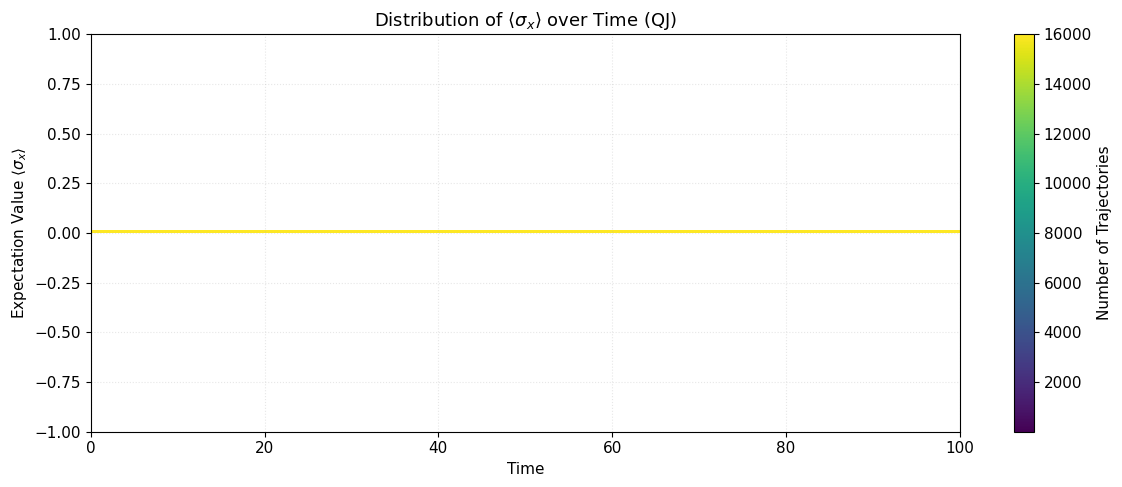

Figure saved in: ../Results/Plot/Sxyz_Analysis/Complete/QJ/Sigma_Y/Heatmap_Sigma_Y_QJ


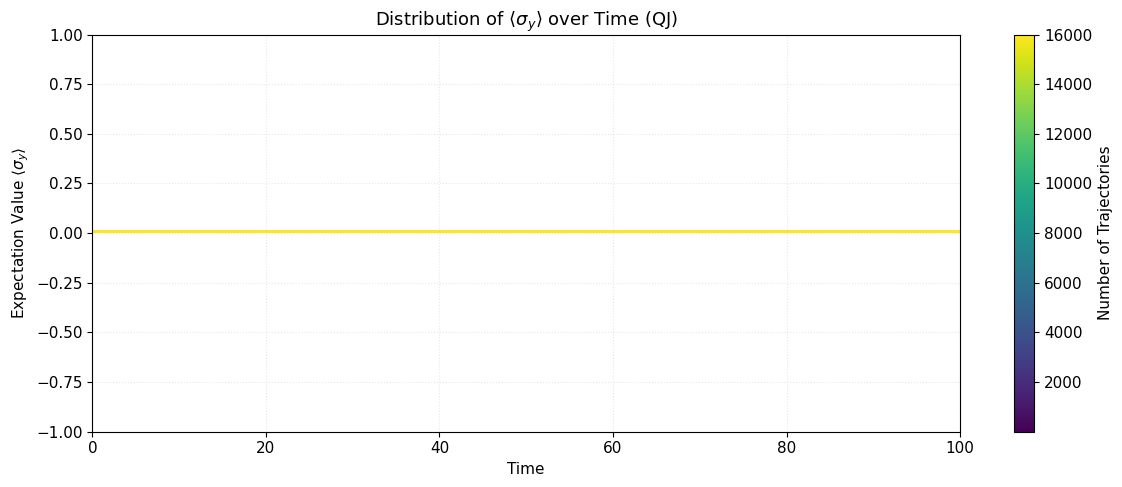

Figure saved in: ../Results/Plot/Sxyz_Analysis/Complete/QJ/Sigma_Z/Heatmap_Sigma_Z_QJ


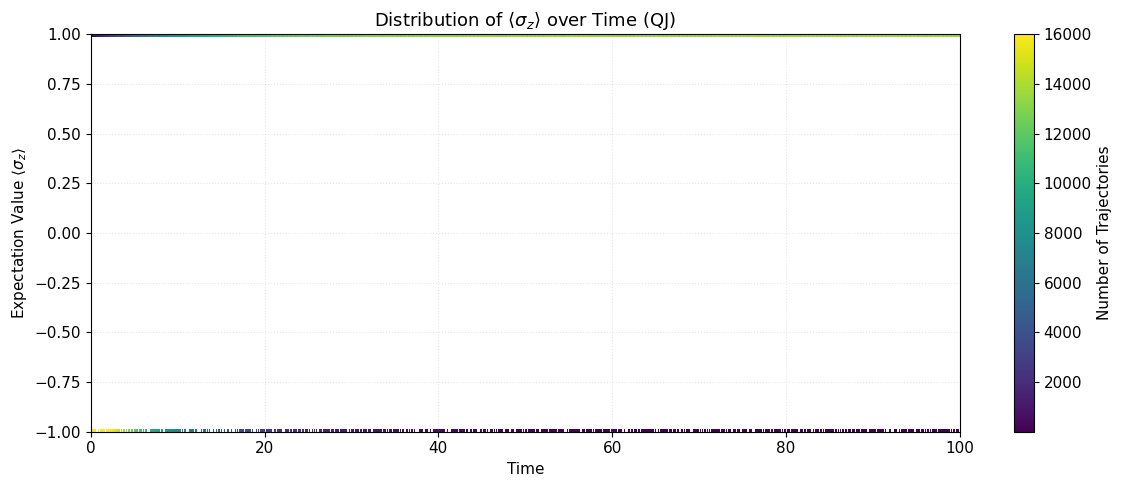

In [10]:
# ==============================================================
# PLOT HEATMAP COMPLETE: PAULI EXPECTATION VALUES (Sx, Sy, Sz)
# ==============================================================
import matplotlib.pyplot as plt
import numpy as np
import os

plt.close('all')

# Ensure we have the correct dimensions from the previously calculated arrays
# all_sigma_... arrays have shape (n_times, n_traj)
n_times, n_traj = all_sigma_x.shape

# Heatmap bin parameters (Pauli expectation values range from -1 to 1)
n_bins = 150 
pauli_bins = np.linspace(-1.0, 1.0, n_bins + 1)

# List of the matrices and their corresponding LaTeX labels and filenames
matrices = [all_sigma_x, all_sigma_y, all_sigma_z]
labels = [r'\sigma_x', r'\sigma_y', r'\sigma_z']
filenames = ['Sigma_X', 'Sigma_Y', 'Sigma_Z']

# Loop over the 3 expectation values to generate 3 separate heatmap plots
for sigma_matrix, label, file_suffix in zip(matrices, labels, filenames):
    
    # Initialize an empty heatmap for the current Pauli matrix: shape (n_bins, n_times)
    heatmap_complete = np.zeros((n_bins, n_times))
    
    # Compute the histogram for each time step across all trajectories
    for t in range(n_times):
        counts, _ = np.histogram(sigma_matrix[t, :], bins=pauli_bins)
        heatmap_complete[:, t] = counts

    # Create the figure
    fig, ax = plt.subplots(figsize=(12, 5))

    # Mask zero counts to improve visualization (makes zero-count areas transparent/white)
    heatmap_masked_complete = np.ma.masked_where(heatmap_complete == 0, heatmap_complete) 

    # Plot the heatmap using imshow
    # x-axis is physical time, y-axis is the expectation value range [-1, 1]
    im = ax.imshow(
        heatmap_masked_complete,
        aspect='auto',
        origin='lower',
        extent=[times[0], times[-1], -1.0, 1.0], 
        cmap='viridis',                          
        interpolation='nearest',
        vmin=1, 
        vmax=np.max(heatmap_complete) * 0.8 # Slightly saturate the colorbar for better contrast
    )

    # Add colorbar
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label('Number of Trajectories')

    # Apply labels and dynamic title using the current simulation MODE
    ax.set_xlabel('Time')
    ax.set_ylabel(f'Expectation Value $\\langle {label} \\rangle$')
    ax.set_title(f'Distribution of $\\langle {label} \\rangle$ over Time ({MODE})')

    # Automatically save the figure 
    Output_dir = os.path.join(base_output_dir, file_suffix)
    if not os.path.exists(Output_dir):
        os.makedirs(Output_dir)
    save_fig(fig, f"Heatmap_{file_suffix}_{MODE}")

    plt.show()

Figure saved in: ../Results/Plot/Sxyz_Analysis/Complete/QJ/Sigma_X/Avg_Sigma_X_Evolution_QJ


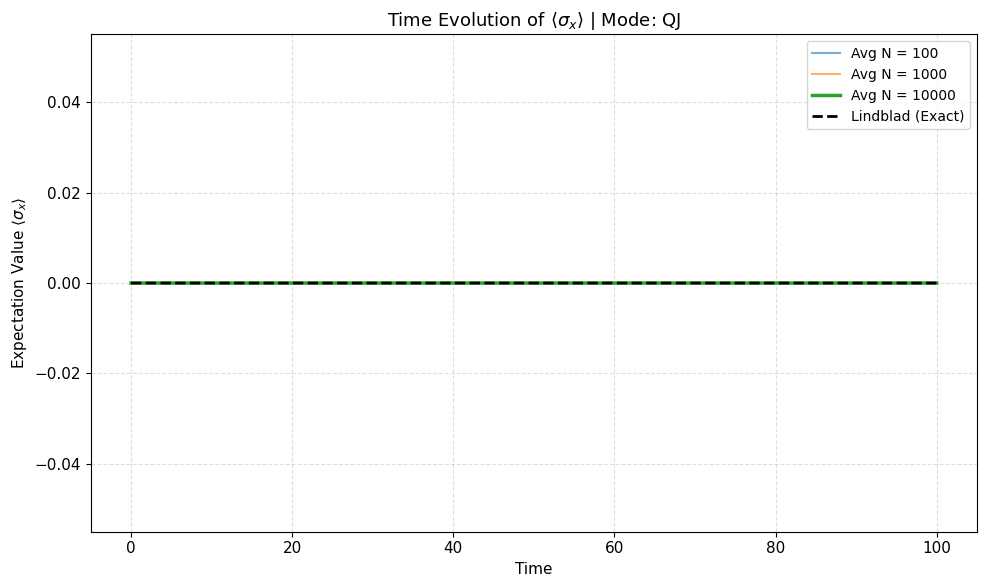

Figure saved in: ../Results/Plot/Sxyz_Analysis/Complete/QJ/Sigma_Y/Avg_Sigma_Y_Evolution_QJ


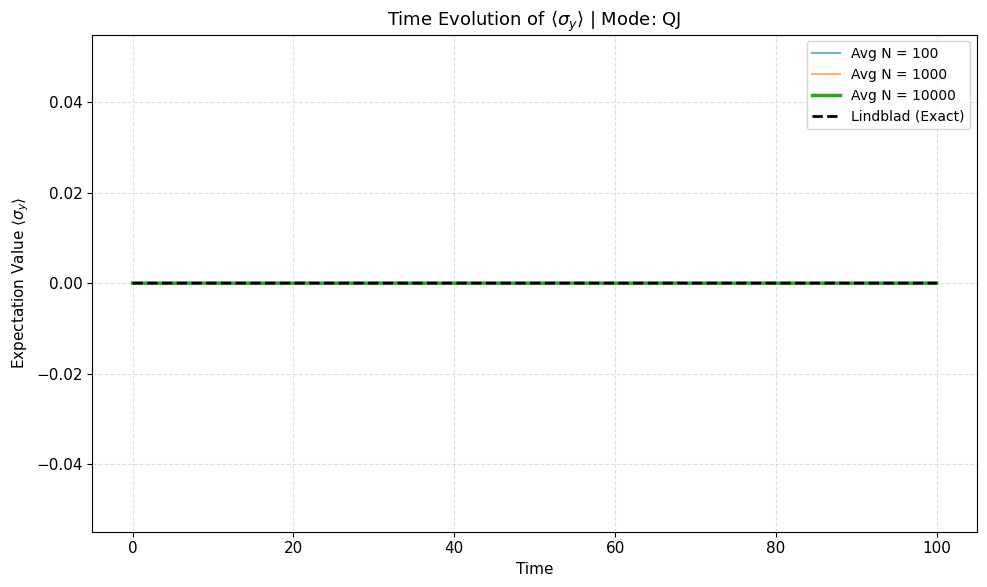

Figure saved in: ../Results/Plot/Sxyz_Analysis/Complete/QJ/Sigma_Z/Avg_Sigma_Z_Evolution_QJ


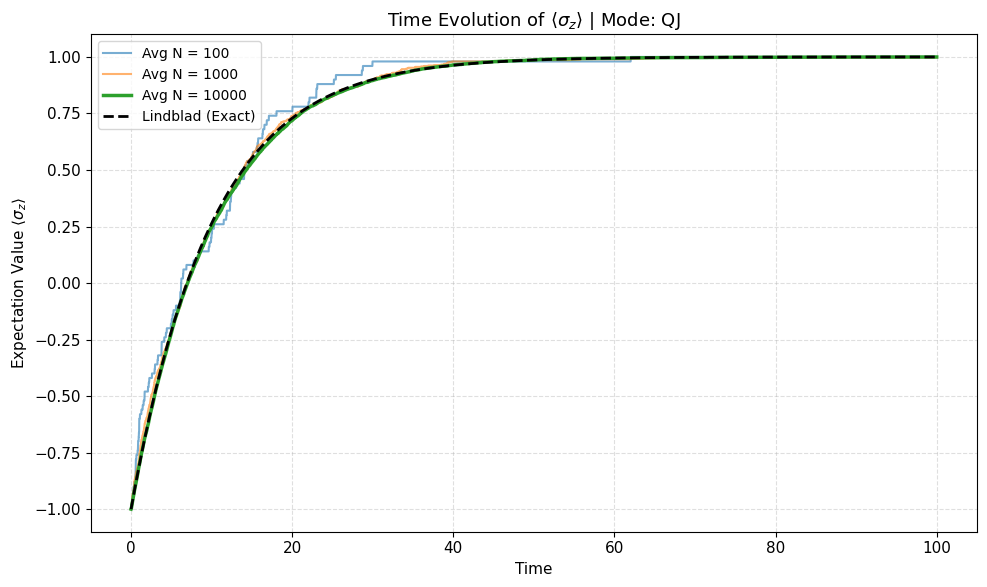

In [11]:
# ======================================================
# PLOT EXPECTATION VALUES: AVG TRAJECTORIES VS LINDBLAD
# ======================================================

plt.close('all')

# 1. Group the already calculated Lindblad and Trajectory data
# We use the arrays calculated in the previous cells
lindblad_expectations = [lindblad_sx, lindblad_sy, lindblad_sz]
trajectory_matrices = [all_sigma_x, all_sigma_y, all_sigma_z]
labels = [r'\sigma_x', r'\sigma_y', r'\sigma_z']
filenames = ['Sigma_X', 'Sigma_Y', 'Sigma_Z']

# List of trajectory counts to average over for comparison
N_list = [100, 1000, 10000]

# 2. Loop over the 3 Pauli observables (Sx, Sy, Sz)
for traj_matrix, lind_array, label, file_suffix in zip(trajectory_matrices, lindblad_expectations, labels, filenames):
    
    # Create a new figure for each observable
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # 3. Plot the ensemble average for different N values
    for N in N_list:
        # Check if we have enough trajectories in the data
        if N > traj_matrix.shape[1]:
            continue
            
        # Calculate the mean over the first N trajectories (along axis 1)
        avg_traj = np.mean(traj_matrix[:, :N], axis=1)
        
        # Dynamic styling: thicker line and full opacity for the largest N
        alpha_val = 0.6 if N < max(N_list) else 1.0
        lw = 1.5 if N < max(N_list) else 2.5
        
        # Plot using the physical time array
        ax.plot(times, avg_traj, label=f'Avg N = {N}', alpha=alpha_val, linewidth=lw)
    
    # 4. Plot the exact Lindblad solution as a reference (dashed black line)
    ax.plot(times, lind_array, label='Lindblad (Exact)', color='black', linestyle='--', linewidth=2.0)
    
    # 5. Formatting
    ax.set_xlabel("Time")
    ax.set_ylabel(f"Expectation Value $\\langle {label} \\rangle$")
    ax.set_title(f"Time Evolution of $\\langle {label} \\rangle$ | Mode: {MODE}")
    ax.legend()
    ax.grid(alpha=0.4, linestyle='--')
    fig.tight_layout()
    
    # 6. Automated Saving 
    Output_dir = os.path.join(base_output_dir, file_suffix)
    if not os.path.exists(Output_dir):
        os.makedirs(Output_dir)

    save_filename = f"Avg_{file_suffix}_Evolution_{MODE}"
    save_fig(fig, save_filename)

    plt.show()

Calculating variances across all trajectories for mode: QJ
Figure saved in: ../Results/Plot/Sxyz_Analysis/Complete/QJ/Variance_Pauli_Comparison_QJ


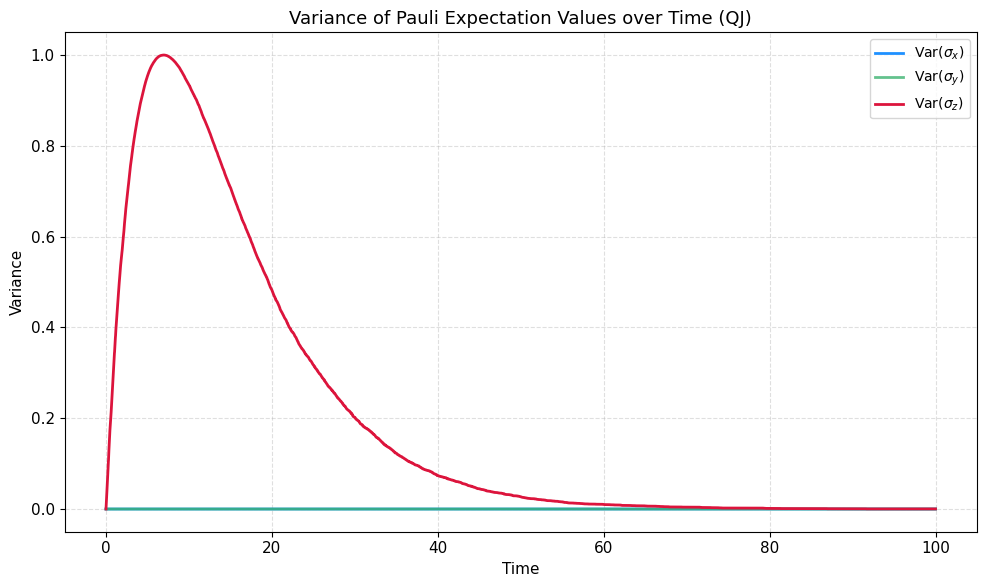

In [12]:
# =================================================
# VARIANCE CALCULATION AND PLOT FOR PAULI MATRICES
# =================================================

print(f"Calculating variances across all trajectories for mode: {MODE}")

# 1. Calculate the variance for each time step across all trajectories (axis=1)
# These represent the stochastic spread of the individual quantum paths
variance_sx = np.var(all_sigma_x, axis=1)
variance_sy = np.var(all_sigma_y, axis=1)
variance_sz = np.var(all_sigma_z, axis=1)

# 2. Plotting the variances together for comparison
plt.close('all')

fig, ax = plt.subplots(figsize=(10, 6))

# Plot the three variances with distinct colors
ax.plot(times, variance_sx, label=r'Var($\sigma_x$)', color='dodgerblue', linewidth=2)
ax.plot(times, variance_sy, label=r'Var($\sigma_y$)', color='mediumseagreen', linewidth=2, alpha=0.8)
ax.plot(times, variance_sz, label=r'Var($\sigma_z$)', color='crimson', linewidth=2)

# Set labels and dynamic titles
ax.set_xlabel("Time")
ax.set_ylabel("Variance")
ax.set_title(f"Variance of Pauli Expectation Values over Time ({MODE})")

# Add legend and grid for clarity
ax.legend(loc='best')
ax.grid(alpha=0.4, linestyle='--')

fig.tight_layout()

# 3. Automatically save the figure 
Output_dir = base_output_dir  # Use the same base output directory for variance plot

filename_var_pauli = f"Variance_Pauli_Comparison_{MODE}"
save_fig(fig, filename_var_pauli)

plt.show()

In [13]:
# # ==========================================================
# # SAVE COMPLETE PAULI MATRICES AND VARIANCES
# # ==========================================================

# # 1. Define the main subdirectory and the specific ones for each observable
# main_subdir = "pauli_exp_value"

# dir_sx = os.path.join(Input_dir, main_subdir, "Sx")
# dir_sy = os.path.join(Input_dir, main_subdir, "Sy")
# dir_sz = os.path.join(Input_dir, main_subdir, "Sz")

# # 2. Check and create directories if they do not exist
# for directory in [dir_sx, dir_sy, dir_sz]:
#     if not os.path.exists(directory):
#         os.makedirs(directory)
#         print(f"Created directory: {directory}")

# # 3. Define the output filepaths for each observable
# # Using theta_target_deg to distinguish between different angles
# filepath_sx = os.path.join(dir_sx, f"Complete_Sx_Theta_{theta_target_deg}deg.npz")
# filepath_sy = os.path.join(dir_sy, f"Complete_Sy_Theta_{theta_target_deg}deg.npz")
# filepath_sz = os.path.join(dir_sz, f"Complete_Sz_Theta_{theta_target_deg}deg.npz")

# # 4. Save the full matrices and their calculated variances into separate compressed .npz files
# # Saving the time array alongside the complete matrices and variances
# np.savez_compressed(filepath_sx, times=times, all_sigma_x=all_sigma_x, var_sx=variance_sx)
# np.savez_compressed(filepath_sy, times=times, all_sigma_y=all_sigma_y, var_sy=variance_sy)
# np.savez_compressed(filepath_sz, times=times, all_sigma_z=all_sigma_z, var_sz=variance_sz)

# print(f"✅ Complete Sx data and variance successfully saved in: {filepath_sx}")
# print(f"✅ Complete Sy data and variance successfully saved in: {filepath_sy}")
# print(f"✅ Complete Sz data and variance successfully saved in: {filepath_sz}")

## Variance Comparison